<a href="https://colab.research.google.com/github/Khulbe-Nitin/Volt-Relay/blob/main/Collab_notebook/Nitin_4_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# VoltRelay Energy - Data Analytics Hackathon
# Author: Khulbe
# Dataset: Synthetic Battery-Swapping Network

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Volt_relay/raw/"

In [ ]:
stations = pd.read_csv(DATA_PATH + "stations.csv")
riders = pd.read_csv(DATA_PATH + "riders.csv")
fleet_partners = pd.read_csv(DATA_PATH + "fleet_partners.csv")
swap_events = pd.read_csv(DATA_PATH + "swap_events.csv")

<h2>Stations - Understanding DataSet</h2>

In [ ]:
print(stations.shape)

(152, 22)


In [ ]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   station_id                     152 non-null    object 
 1   city                           152 non-null    object 
 2   zone                           152 non-null    object 
 3   latitude                       152 non-null    float64
 4   longitude                      152 non-null    float64
 5   location_type                  152 non-null    object 
 6   host_type                      152 non-null    object 
 7   commissioned_date              152 non-null    object 
 8   decommissioned_date            1 non-null      object 
 9   expansion_wave                 152 non-null    object 
 10  charger_generation             152 non-null    object 
 11  slots_2w                       152 non-null    int64  
 12  slots_3w                       152 non-null    int

In [ ]:
display(stations.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
station_id,152,152,STN-BLR-001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,152,6,Bengaluru,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,152,28,PUN-South,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,152.0,NaN,NaN,NaN,20.130857,5.73694,12.799911,17.234749,18.591899,26.850718,28.747185
longitude,152.0,NaN,NaN,NaN,76.214074,1.994029,72.886092,73.770932,77.101079,77.605381,78.59181
location_type,152,6,market,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_type,152,4,mall_parking,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
commissioned_date,152,117,2023-11-07,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
decommissioned_date,1,1,2025-05-20,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expansion_wave,152,3,Launch,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
display(stations.isna().sum().sort_values(ascending=False))

,0
decommissioned_date,151
competitor_within_1_5km_since,142
zone,0
latitude,0
station_id,0
city,0
location_type,0
longitude,0
commissioned_date,0
host_type,0


In [ ]:
print("Duplicate rows:", stations.duplicated().sum())
print("Duplicate station IDs:", stations["station_id"].duplicated().sum())

Duplicate rows: 0
Duplicate station IDs: 0


In [ ]:
categorical_columns = [
    "city",
    "zone",
    "location_type",
    "host_type",
    "expansion_wave",
    "charger_generation",
    "connectivity_tier",
    "firmware_version"
]

for col in categorical_columns:
    print("\n" + "=" * 50)
    print(col)
    print("=" * 50)
    print(stations[col].value_counts(dropna=False))


city
city
Bengaluru    34
Delhi NCR    30
Hyderabad    26
Pune         22
Mumbai       22
Jaipur       18
Name: count, dtype: int64

zone
zone
PUN-South              12
BLR-Central            10
HYD-Central            10
JAI-Malviya Nagar      10
MUM-Andheri             9
BLR-East                8
DEL-West                8
MUM-Central             8
DEL-East                7
PUN-Central             7
JAI-Vaishali            7
BLR-Electronic City     7
DEL-Noida               6
HYD-Secunderabad        6
HYD-Hitech City         5
DEL-Gurugram-Cyber      5
BLR-Whitefield          4
MUM-Navi Mumbai         3
DEL-South               3
BLR-North               3
HYD-West                3
BLR-South               2
PUN-Hinjewadi           2
HYD-South               2
MUM-Thane               2
DEL-Central             1
PUN-Kharadi             1
JAI-Central             1
Name: count, dtype: int64

location_type
location_type
market               47
commercial_hub       46
highway_fuel_pump    21
r

In [ ]:
numeric_columns = [
    "latitude",
    "longitude",
    "slots_2w",
    "slots_3w",
    "inventory_target_2w",
    "inventory_target_3w",
    "monthly_rent_inr",
    "monthly_maintenance_inr",
    "grid_tariff_inr_kwh"
]

display(stations[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
latitude,152.0,20.130857,5.736940,12.799911,17.234749,18.591899,26.850718,28.747185
longitude,152.0,76.214074,1.994029,72.886092,73.770932,77.101079,77.605381,78.591810
slots_2w,152.0,12.289474,3.225789,8.000000,8.000000,12.000000,16.000000,16.000000
slots_3w,152.0,2.223684,2.599535,0.000000,0.000000,0.000000,4.000000,6.000000
inventory_target_2w,152.0,22.578947,9.701182,6.000000,15.000000,21.000000,29.000000,46.000000
inventory_target_3w,152.0,2.657895,3.105443,0.000000,0.000000,0.000000,5.000000,8.000000
monthly_rent_inr,152.0,17707.480263,6354.331398,9054.000000,12169.500000,16901.500000,22012.250000,35719.000000
monthly_maintenance_inr,152.0,5932.822368,879.811239,4503.000000,5075.500000,5890.000000,6687.750000,7497.000000
grid_tariff_inr_kwh,152.0,9.301579,0.772910,7.500000,8.785000,9.215000,9.787500,11.700000


In [ ]:
#for Displaying nonsensical values
for col in numeric_columns:
    print(f"\n{col}")
    print("Min:", stations[col].min())
    print("Max:", stations[col].max())


latitude
Min: 12.799911
Max: 28.747185

longitude
Min: 72.886092
Max: 78.59181

slots_2w
Min: 8
Max: 16

slots_3w
Min: 0
Max: 6

inventory_target_2w
Min: 6
Max: 46

inventory_target_3w
Min: 0
Max: 8

monthly_rent_inr
Min: 9054
Max: 35719

monthly_maintenance_inr
Min: 4503
Max: 7497

grid_tariff_inr_kwh
Min: 7.5
Max: 11.7


In [ ]:
date_columns = [
    "commissioned_date",
    "decommissioned_date",
    "firmware_updated_date",
    "competitor_within_1_5km_since"
]

for col in date_columns:
    stations[col] = pd.to_datetime(
        stations[col],
        errors="coerce"
    )

In [ ]:
display(stations[date_columns].describe().T)

,count,mean,min,25%,50%,75%,max
commissioned_date,152,2024-03-12 12:37:53.684210432,2023-06-01 00:00:00,2023-08-26 00:00:00,2023-11-14 12:00:00,2024-10-08 12:00:00,2025-04-28 00:00:00
decommissioned_date,1,2025-05-20 00:00:00,2025-05-20 00:00:00,2025-05-20 00:00:00,2025-05-20 00:00:00,2025-05-20 00:00:00,2025-05-20 00:00:00
firmware_updated_date,152,2025-03-30 22:53:41.052631552,2025-03-10 00:00:00,2025-03-10 00:00:00,2025-04-14 00:00:00,2025-04-14 00:00:00,2025-04-14 00:00:00
competitor_within_1_5km_since,10,2025-01-15 00:00:00,2025-01-15 00:00:00,2025-01-15 00:00:00,2025-01-15 00:00:00,2025-01-15 00:00:00,2025-01-15 00:00:00


In [ ]:
# Since decommissioning cannot happen before commissioning
invalid_dates = stations[
    stations["decommissioned_date"].notna() &
    (stations["decommissioned_date"] < stations["commissioned_date"])
]

display(invalid_dates)

,station_id,city,zone,latitude,longitude,location_type,host_type,commissioned_date,decommissioned_date,expansion_wave,...,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since


In [ ]:
missing = stations.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(missing)

,0
decommissioned_date,151
competitor_within_1_5km_since,142


In [ ]:
#replacing the missing values from the columns
stations["is_active"] = stations["decommissioned_date"].isna()
stations["has_nearby_competitor"] = (
    stations["competitor_within_1_5km_since"].notna()
)

In [ ]:
#Now I am creating some features to the dataset
stations["total_slots"] = (
    stations["slots_2w"] +
    stations["slots_3w"]
) #total_slots
stations["total_inventory_target"] = (
    stations["inventory_target_2w"] +
    stations["inventory_target_3w"]
) #total_inventory

#Fixed monthly station cost
stations["monthly_fixed_cost_inr"] = (
    stations["monthly_rent_inr"] +
    stations["monthly_maintenance_inr"]
)

In [ ]:
#Station age in days and months
analysis_date = pd.Timestamp("2025-06-30")

stations["station_age_days"] = (
    analysis_date - stations["commissioned_date"]
).dt.days

stations["station_age_months"] = (
    stations["station_age_days"] / 30
).round(1)

<h1> EDA- Station </h1>

In [ ]:
city_counts = stations["city"].value_counts()

display(city_counts)

,count
city,
Bengaluru,34
Delhi NCR,30
Hyderabad,26
Pune,22
Mumbai,22
Jaipur,18


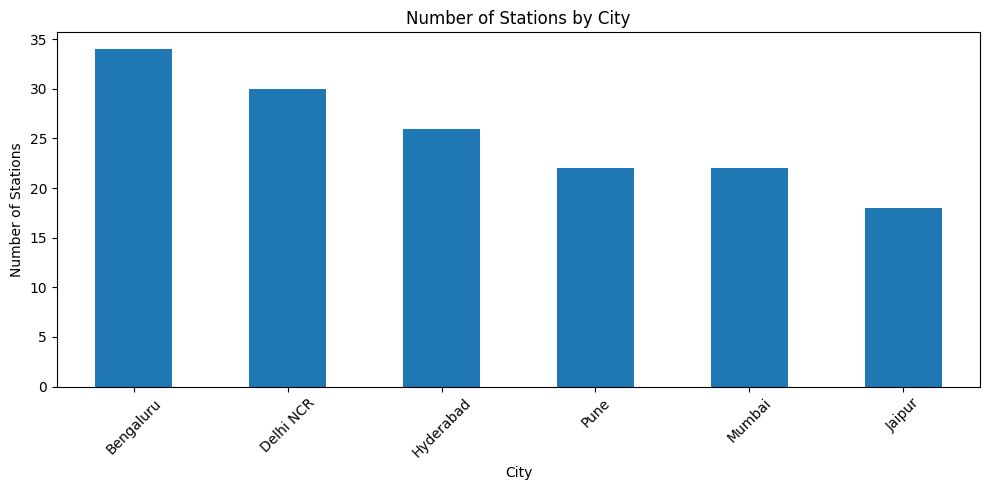

In [ ]:
plt.figure(figsize=(10, 5))

city_counts.plot(kind="bar")

plt.title("Number of Stations by City")
plt.xlabel("City")
plt.ylabel("Number of Stations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#plot depicting Stations density by city

In [ ]:
#charger generation
display(
    pd.crosstab(
        stations["city"],
        stations["charger_generation"]
    )
)
#Location
display(
    stations["location_type"].value_counts()
)

charger_generation,Gen1,Gen2,Gen3
city,,,
Bengaluru,9,18,7
Delhi NCR,13,10,7
Hyderabad,13,6,7
Jaipur,10,3,5
Mumbai,2,15,5
Pune,4,12,6


,count
location_type,
market,47
commercial_hub,46
highway_fuel_pump,21
residential,21
transit_hub,10
tech_park,7


In [ ]:
#Station's economic feature
display(
    stations[
        [
            "city",
            "monthly_rent_inr",
            "monthly_maintenance_inr",
            "monthly_fixed_cost_inr",
            "grid_tariff_inr_kwh"
        ]
    ].groupby("city").mean().round(2)
)

,monthly_rent_inr,monthly_maintenance_inr,monthly_fixed_cost_inr,grid_tariff_inr_kwh
city,,,,
Bengaluru,15720.09,6130.85,21850.94,9.28
Delhi NCR,16155.57,6029.07,22184.63,9.18
Hyderabad,17191.77,5677.12,22868.88,9.07
Jaipur,17022.72,5895.78,22918.50,9.06
Mumbai,25843.41,5667.73,31511.14,10.16
Pune,15928.95,6093.14,22022.09,9.12


In [ ]:
stations.columns.tolist()

['station_id',
 'city',
 'zone',
 'latitude',
 'longitude',
 'location_type',
 'host_type',
 'commissioned_date',
 'decommissioned_date',
 'expansion_wave',
 'charger_generation',
 'slots_2w',
 'slots_3w',
 'inventory_target_2w',
 'inventory_target_3w',
 'monthly_rent_inr',
 'monthly_maintenance_inr',
 'grid_tariff_inr_kwh',
 'connectivity_tier',
 'firmware_version',
 'firmware_updated_date',
 'competitor_within_1_5km_since',
 'is_active',
 'has_nearby_competitor',
 'total_slots',
 'total_inventory_target',
 'monthly_fixed_cost_inr',
 'station_age_days',
 'station_age_months']

<h1> <b> #2 Dataset </b></h1> <h1> **Riders** </h1>

In [ ]:
print("Shape:", riders.shape)

display(riders.head())

riders.info()

Shape: (20000, 12)


,rider_id,partner_id,vehicle_class,vehicle_model,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,home_city
0,RD-1000000,FP-04,3W,Kranti Cargo3,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,Delhi NCR
1,RD-1000001,FP-05,2W,Volt Cub,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,Mumbai
2,RD-1000002,FP-06,2W,Torq X1,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,Hyderabad
3,RD-1000003,FP-01,2W,Zipp E2,MUM-Navi Mumbai,2023-03-08,partner_onboarding,partner_billed,evening,25-34,True,Mumbai
4,RD-1000004,FP-02,2W,Zipp E2,HYD-Hitech City,2023-03-08,partner_onboarding,partner_billed,night,NaN,True,Hyderabad


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rider_id        20000 non-null  object
 1   partner_id      12372 non-null  object
 2   vehicle_class   20000 non-null  object
 3   vehicle_model   20000 non-null  object
 4   home_zone       20000 non-null  object
 5   signup_date     20000 non-null  object
 6   signup_channel  20000 non-null  object
 7   plan_type       20000 non-null  object
 8   declared_shift  16338 non-null  object
 9   age_band        18453 non-null  object
 10  kyc_verified    20000 non-null  bool  
 11  home_city       20000 non-null  object
dtypes: bool(1), object(11)
memory usage: 1.7+ MB


In [ ]:
display(riders.isna().sum().sort_values(ascending=False))

,0
partner_id,7628
declared_shift,3662
age_band,1547
rider_id,0
vehicle_model,0
vehicle_class,0
home_zone,0
signup_date,0
plan_type,0
signup_channel,0


In [ ]:
print("Duplicate rows:", riders.duplicated().sum())
print("Duplicate rider IDs:", riders["rider_id"].duplicated().sum())
print("Unique riders:", riders["rider_id"].nunique())

Duplicate rows: 0
Duplicate rider IDs: 0
Unique riders: 20000


In [ ]:
display(riders.describe(include="all").T)

,count,unique,top,freq
rider_id,20000,20000,RD-1019983,1
partner_id,12372,12,FP-01,2710
vehicle_class,20000,2,2W,17107
vehicle_model,20000,8,Zipp E2,5674
home_zone,20000,28,JAI-Malviya Nagar,1528
signup_date,20000,817,2024-10-22,68
signup_channel,20000,4,partner_onboarding,9376
plan_type,20000,3,partner_billed,12372
declared_shift,16338,4,evening,5961
age_band,18453,4,25-34,6878


In [ ]:
#We notice that there are some riders without a partner id. These are individual riders, so we group them
#based on whehter they have a plan with a partner or not.
# ============================================
# RIDERS - PARTNER CONSISTENCY
# ============================================

print("Plan type distribution:")
display(riders["plan_type"].value_counts(dropna=False))

print("\nPartner ID missing by plan type:")
display(
    riders.groupby("plan_type")["partner_id"]
    .apply(lambda x: x.isna().sum())
)

Plan type distribution:


,count
plan_type,
partner_billed,12372
pay_as_you_go,5299
prepaid_pack,2329



Partner ID missing by plan type:


,partner_id
plan_type,
partner_billed,0
pay_as_you_go,5299
prepaid_pack,2329


In [ ]:
print("\nPlan type for riders WITH partner_id:")
display(
    riders.loc[riders["partner_id"].notna(), "plan_type"]
    .value_counts(dropna=False)
)

print("\nPlan type for riders WITHOUT partner_id:")
display(
    riders.loc[riders["partner_id"].isna(), "plan_type"]
    .value_counts(dropna=False)
)


Plan type for riders WITH partner_id:


,count
plan_type,
partner_billed,12372



Plan type for riders WITHOUT partner_id:


,count
plan_type,
pay_as_you_go,5299
prepaid_pack,2329


In [ ]:
riders["is_fleet_rider"] = riders["partner_id"].notna()

In [ ]:
display(
    riders["partner_id"]
    .value_counts(dropna=False)
)
print("Unique non-null partners:",
      riders["partner_id"].nunique())

,count
partner_id,
NaN,7628
FP-01,2710
FP-03,2381
FP-02,1766
FP-05,1254
FP-04,869
FP-06,608
FP-07,532
FP-10,519


Unique non-null partners: 12


In [ ]:
#Problem statement warns about home_city, so we are checking home_cities inconsistency
display(
    riders["home_city"]
    .value_counts()
)
print("Number of home cities", riders["home_city"].nunique())

,count
home_city,
Bengaluru,4175
Delhi NCR,3783
Hyderabad,3396
Pune,2843
Mumbai,2772
Jaipur,2446
Bombay,53
BLR,53
bengaluru,50


Number of home cities 21


In [ ]:
display(
    riders[
        ["home_city", "home_zone"]
    ]
    .drop_duplicates()
    .sort_values(["home_city", "home_zone"])
    .to_string(index=False)
)

' home_city           home_zone\n       BLR         BLR-Central\n       BLR            BLR-East\n       BLR BLR-Electronic City\n       BLR           BLR-North\n       BLR           BLR-South\n       BLR      BLR-Whitefield\n Bangalore         BLR-Central\n Bangalore            BLR-East\n Bangalore BLR-Electronic City\n Bangalore           BLR-North\n Bangalore           BLR-South\n Bangalore      BLR-Whitefield\n Bengaluru         BLR-Central\n Bengaluru            BLR-East\n Bengaluru BLR-Electronic City\n Bengaluru           BLR-North\n Bengaluru           BLR-South\n Bengaluru      BLR-Whitefield\n    Bombay         MUM-Andheri\n    Bombay         MUM-Central\n    Bombay     MUM-Navi Mumbai\n    Bombay           MUM-Thane\n     Delhi         DEL-Central\n     Delhi            DEL-East\n     Delhi  DEL-Gurugram-Cyber\n     Delhi           DEL-Noida\n     Delhi           DEL-South\n     Delhi            DEL-West\n Delhi NCR         DEL-Central\n Delhi NCR            DEL-East\n Delhi 

<h3> Checking vehicle info </h3>

In [ ]:
display(riders["vehicle_class"].value_counts())

print("\nVehicle models:")
display(riders["vehicle_model"].value_counts())

,count
vehicle_class,
2W,17107
3W,2893



Vehicle models:


,count
vehicle_model,
Zipp E2,5674
Kranti Spark,2370
Volt Cub,2283
Orbit Lite,2273
Torq X1,2271
Nova Ray,2236
Kranti Cargo3,1492
Torq Hauler,1401


In [ ]:
display(
    pd.crosstab(
        riders["vehicle_class"],
        riders["vehicle_model"]
    )
)

vehicle_model,Kranti Cargo3,Kranti Spark,Nova Ray,Orbit Lite,Torq Hauler,Torq X1,Volt Cub,Zipp E2
vehicle_class,,,,,,,,
2W,0,2370,2236,2273,0,2271,2283,5674
3W,1492,0,0,0,1401,0,0,0


<h2> DATA PROCESSING </h2>

In [ ]:
riders["signup_date"] = pd.to_datetime(
    riders["signup_date"],
    errors="coerce"
)

print("Missing signup dates:",
      riders["signup_date"].isna().sum())

print("Earliest signup:",
      riders["signup_date"].min())

print("Latest signup:",
      riders["signup_date"].max())

Missing signup dates: 0
Earliest signup: 2023-03-08 00:00:00
Latest signup: 2025-06-30 00:00:00


In [ ]:
display(
    riders["signup_date"].describe()
)

,signup_date
count,20000
mean,2024-08-12 09:43:16.320000
min,2023-03-08 00:00:00
25%,2024-03-12 00:00:00
50%,2024-09-30 00:00:00
75%,2025-02-17 00:00:00
max,2025-06-30 00:00:00


<h2> Feature Engineering </h2>

In [ ]:
#Signup Features
riders["signup_year"] = (
    riders["signup_date"].dt.year
)

riders["signup_month"] = (
    riders["signup_date"].dt.month
)

riders["signup_month_name"] = (
    riders["signup_date"].dt.strftime("%b")
)

riders["signup_year_month"] = (
    riders["signup_date"].dt.to_period("M")
    .astype(str)
)

In [ ]:
riders["signup_day_of_week"] = (
    riders["signup_date"].dt.day_name()
)

In [ ]:
#Fleet_rider Features
riders["is_fleet_rider"] = (
    riders["partner_id"].notna()
)

In [ ]:
display(
    riders["is_fleet_rider"].value_counts()
)

,count
is_fleet_rider,
True,12372
False,7628


In [ ]:
# Just displaying it out of 100
display(
    riders["is_fleet_rider"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
riders["partner_id"].isna().sum(

)

,proportion
is_fleet_rider,
True,61.86
False,38.14


np.int64(7628)

In [ ]:
#filling missing values in declared_shifts and Age_band
riders["declared_shift_clean"] = (
    riders["declared_shift"]
    .fillna("Not declared")
)

riders["age_band_clean"] = (
    riders["age_band"]
    .fillna("Not declared")
)

In [ ]:
display(
    riders["declared_shift_clean"].value_counts()
)

display(
    riders["age_band_clean"].value_counts()
)

,count
declared_shift_clean,
evening,5961
day,4366
Not declared,3662
mixed,3185
night,2826


,count
age_band_clean,
25-34,6878
18-24,5608
35-44,4024
45+,1943
Not declared,1547


In [ ]:
#KYC has NO Missing values and has only 2 unique values
display(
    riders["kyc_verified"].value_counts(dropna=False)
)

,count
kyc_verified,
True,19254
False,746


In [ ]:
print(
    "KYC verification rate:",
    round(riders["kyc_verified"].mean() * 100, 2),
    "%"
)

KYC verification rate: 96.27 %


<h1> Basic EDA </h1>

In [ ]:
#Riders by vehicle class 2W, 3W
vehicle_class_counts = (
    riders["vehicle_class"]
    .value_counts()
)

display(vehicle_class_counts)

,count
vehicle_class,
2W,17107
3W,2893


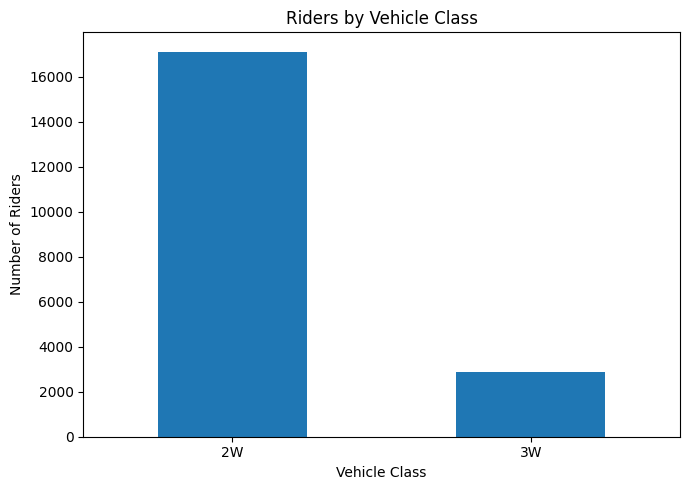

In [ ]:
#Plotting riders by class
plt.figure(figsize=(7, 5))

vehicle_class_counts.plot(kind="bar")

plt.title("Riders by Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Number of Riders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#rider by channel
display(
    riders["signup_channel"].value_counts()
)

,count
signup_channel,
partner_onboarding,9376
app_store,4215
field_agent,4144
referral,2265


In [ ]:
#riders by plan
display(
    riders["plan_type"].value_counts()
)

,count
plan_type,
partner_billed,12372
pay_as_you_go,5299
prepaid_pack,2329


In [ ]:
#Fleet vs Independent riders
display(
    riders["is_fleet_rider"].value_counts()
)

,count
is_fleet_rider,
True,12372
False,7628


In [ ]:
#Cross analysis b/w different features
fleet_by_vehicle = pd.crosstab(
    riders["vehicle_class"],
    riders["is_fleet_rider"]
)

display(fleet_by_vehicle)

is_fleet_rider,False,True
vehicle_class,,
2W,6956,10151
3W,672,2221


In [ ]:
plan_by_vehicle = pd.crosstab(
    riders["vehicle_class"],
    riders["plan_type"]
)

display(plan_by_vehicle)

plan_type,partner_billed,pay_as_you_go,prepaid_pack
vehicle_class,,,
2W,10151,4823,2133
3W,2221,476,196


In [ ]:
#Signup vs Plan_type
channel_by_plan = pd.crosstab(
    riders["signup_channel"],
    riders["plan_type"]
)

display(channel_by_plan)

plan_type,partner_billed,pay_as_you_go,prepaid_pack
signup_channel,,,
app_store,0,2924,1291
field_agent,2996,795,353
partner_onboarding,9376,0,0
referral,0,1580,685


In [ ]:
#Checking whether fleet-rider and independent rider differ by signup channels
display(
    pd.crosstab(
        riders["signup_channel"],
        riders["is_fleet_rider"],
        normalize="index"
    ).round(3) * 100
)

is_fleet_rider,False,True
signup_channel,,
app_store,100.0,0.0
field_agent,27.7,72.3
partner_onboarding,0.0,100.0
referral,100.0,0.0


<h1> <b> Saving Cleaned Riders and Stations file </h1> </b>

In [ ]:
CLEAN_PATH = "/content/drive/MyDrive/Volt_relay/cleaned/"

In [ ]:
riders.to_csv(
    CLEAN_PATH + "riders_clean.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [ ]:
import os

file_path = CLEAN_PATH + "riders_clean.csv"

print("Exists:", os.path.exists(file_path))
print("File size (MB):", round(os.path.getsize(file_path) / (1024**2), 2))

Exists: True
File size (MB): 2.89


In [ ]:
stations.to_csv(
    CLEAN_PATH + "stations_clean.csv",
    index=False
)

print("Stations dataset saved successfully.")

Stations dataset saved successfully.


In [ ]:
import os

file_path = CLEAN_PATH + "stations_clean.csv"

print("Exists:", os.path.exists(file_path))
print("File size (MB):", round(os.path.getsize(file_path) / (1024**2), 2))

Exists: True
File size (MB): 0.03


<h2> Fleet_Partners </h2>

In [ ]:
# ============================================
# FLEET PARTNERS - DATA UNDERSTANDING
# ============================================

print("Shape:", fleet_partners.shape)

display(fleet_partners.head(20))

fleet_partners.info()

Shape: (12, 12)


,partner_id,partner_name,partner_segment,vehicle_class,contract_type,contract_start_date,discount_pct,amendment_date,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days,cities_active
0,FP-01,FeastFly,food_delivery,2W,volume_tiered,2023-04-01,10.0,NaN,NaN,Y,30,BLR|DEL|HYD|PUN|MUM|JAI
1,FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,2023-07-01,15.0,NaN,NaN,Y,30,BLR|DEL|HYD|MUM
2,FP-03,ZipDrop,quick_commerce,2W,volume_tiered,2023-06-01,12.0,2024-11-01,28.0,N,45,BLR|DEL|HYD|PUN|MUM|JAI
3,FP-04,CargoTuk,cargo_3w,3W,pay_per_swap,2023-09-01,8.0,NaN,NaN,Y,30,DEL|HYD|JAI
4,FP-05,Swiggle Go,food_delivery,2W,volume_tiered,2023-05-01,11.0,NaN,NaN,N,30,BLR|PUN|MUM
5,FP-06,RideMitra,bike_taxi,2W,pay_per_swap,2023-08-01,6.0,NaN,NaN,Y,15,BLR|DEL
6,FP-07,QuickCart,quick_commerce,2W,pay_per_swap,2024-01-15,9.0,NaN,NaN,Y,30,DEL|HYD
7,FP-08,DabbaXpress,food_delivery,2W,pay_per_swap,2024-02-01,8.0,NaN,NaN,Y,30,PUN|MUM
8,FP-09,HaulKing,cargo_3w,3W,pay_per_swap,2023-11-01,7.0,NaN,NaN,Y,45,JAI|DEL
9,FP-10,MetroMove,ecom_logistics,mixed,volume_tiered,2024-03-01,12.0,NaN,NaN,Y,30,BLR|MUM


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   partner_id                    12 non-null     object 
 1   partner_name                  12 non-null     object 
 2   partner_segment               12 non-null     object 
 3   vehicle_class                 12 non-null     object 
 4   contract_type                 12 non-null     object 
 5   contract_start_date           12 non-null     object 
 6   discount_pct                  12 non-null     float64
 7   amendment_date                1 non-null      object 
 8   discount_pct_after_amendment  1 non-null      float64
 9   peak_surcharge_billable       12 non-null     object 
 10  payment_terms_days            12 non-null     int64  
 11  cities_active                 12 non-null     object 
dtypes: float64(2), int64(1), object(9)
memory usage: 1.3+ KB


In [ ]:
print("Missing values:")
display(
    fleet_partners.isna().sum()
    .sort_values(ascending=False)
)

Missing values:


,0
discount_pct_after_amendment,11
amendment_date,11
partner_id,0
partner_name,0
vehicle_class,0
partner_segment,0
contract_start_date,0
contract_type,0
discount_pct,0
peak_surcharge_billable,0


In [ ]:
print("Duplicate rows:", fleet_partners.duplicated().sum())
print(
    "Duplicate partner IDs:",
    fleet_partners["partner_id"].duplicated().sum()
)

Duplicate rows: 0
Duplicate partner IDs: 0


In [ ]:
print(fleet_partners.to_string(index=False))

partner_id partner_name partner_segment vehicle_class contract_type contract_start_date  discount_pct amendment_date  discount_pct_after_amendment peak_surcharge_billable  payment_terms_days           cities_active
     FP-01     FeastFly   food_delivery            2W volume_tiered          2023-04-01          10.0            NaN                           NaN                       Y                  30 BLR|DEL|HYD|PUN|MUM|JAI
     FP-02   ParcelNest  ecom_logistics            2W  pay_per_swap          2023-07-01          15.0            NaN                           NaN                       Y                  30         BLR|DEL|HYD|MUM
     FP-03      ZipDrop  quick_commerce            2W volume_tiered          2023-06-01          12.0     2024-11-01                          28.0                       N                  45 BLR|DEL|HYD|PUN|MUM|JAI
     FP-04     CargoTuk        cargo_3w            3W  pay_per_swap          2023-09-01           8.0            NaN                        

In [ ]:
print(fleet_partners.to_string(index=False))

partner_id partner_name partner_segment vehicle_class contract_type contract_start_date  discount_pct amendment_date  discount_pct_after_amendment peak_surcharge_billable  payment_terms_days           cities_active
     FP-01     FeastFly   food_delivery            2W volume_tiered          2023-04-01          10.0            NaN                           NaN                       Y                  30 BLR|DEL|HYD|PUN|MUM|JAI
     FP-02   ParcelNest  ecom_logistics            2W  pay_per_swap          2023-07-01          15.0            NaN                           NaN                       Y                  30         BLR|DEL|HYD|MUM
     FP-03      ZipDrop  quick_commerce            2W volume_tiered          2023-06-01          12.0     2024-11-01                          28.0                       N                  45 BLR|DEL|HYD|PUN|MUM|JAI
     FP-04     CargoTuk        cargo_3w            3W  pay_per_swap          2023-09-01           8.0            NaN                        

In [ ]:
display(
    fleet_partners.describe(include="all").T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
partner_id,12,12,FP-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
partner_name,12,12,FeastFly,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
partner_segment,12,5,food_delivery,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_class,12,3,2W,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_type,12,2,pay_per_swap,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_start_date,12,12,2023-04-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discount_pct,12.0,NaN,NaN,NaN,9.416667,2.84312,5.0,7.75,9.5,11.25,15.0
amendment_date,1,1,2024-11-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discount_pct_after_amendment,1.0,NaN,NaN,NaN,28.0,NaN,28.0,28.0,28.0,28.0,28.0
peak_surcharge_billable,12,2,Y,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#converting date columns into datetime type
date_columns = [
    "contract_start_date",
    "amendment_date"
]

for col in date_columns:
    fleet_partners[col] = pd.to_datetime(
        fleet_partners[col],
        errors="coerce"
    )

In [ ]:
print(fleet_partners[date_columns].dtypes)

contract_start_date    datetime64[ns]
amendment_date         datetime64[ns]
dtype: object


In [ ]:
#Here we are checking for Nonsensical discounts
print("Negative base discounts:",
      (fleet_partners["discount_pct"] < 0).sum())

print("Discounts above 100%:",
      (fleet_partners["discount_pct"] > 100).sum())

print("Negative amended discounts:",
      (fleet_partners["discount_pct_after_amendment"] < 0).sum())

print("Amended discounts above 100%:",
      (fleet_partners["discount_pct_after_amendment"] > 100).sum())

Negative base discounts: 0
Discounts above 100%: 0
Negative amended discounts: 0
Amended discounts above 100%: 0


In [ ]:
print(
    "Partners with amendment:",
    fleet_partners["amendment_date"].notna().sum()
)

print(
    "Partners with amended discount:",
    fleet_partners["discount_pct_after_amendment"].notna().sum()
)

Partners with amendment: 1
Partners with amended discount: 1


In [ ]:
display(
    fleet_partners[
        [
            "partner_id",
            "discount_pct",
            "amendment_date",
            "discount_pct_after_amendment"
        ]
    ]
)

,partner_id,discount_pct,amendment_date,discount_pct_after_amendment
0,FP-01,10.0,NaT,NaN
1,FP-02,15.0,NaT,NaN
2,FP-03,12.0,2024-11-01,28.0
3,FP-04,8.0,NaT,NaN
4,FP-05,11.0,NaT,NaN
5,FP-06,6.0,NaT,NaN
6,FP-07,9.0,NaT,NaN
7,FP-08,8.0,NaT,NaN
8,FP-09,7.0,NaT,NaN
9,FP-10,12.0,NaT,NaN


In [ ]:
#Checking if the amendment happened after starting date
invalid_amendments = fleet_partners[
    fleet_partners["amendment_date"].notna() &
    (
        fleet_partners["amendment_date"]
        < fleet_partners["contract_start_date"]
    )
]

display(invalid_amendments)

,partner_id,partner_name,partner_segment,vehicle_class,contract_type,contract_start_date,discount_pct,amendment_date,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days,cities_active


In [ ]:
#creating useful features
fleet_partners["has_amendment"] = (
    fleet_partners["amendment_date"].notna()
)
fleet_partners["discount_change_pct_points"] = (
    fleet_partners["discount_pct_after_amendment"]
    - fleet_partners["discount_pct"]
)

In [ ]:
fleet_partners["effective_discount_pct"] = np.where(
    fleet_partners["has_amendment"],
    fleet_partners["discount_pct_after_amendment"],
    fleet_partners["discount_pct"]
)

In [ ]:
display(
    fleet_partners[
        [
            "partner_id",
            "discount_pct",
            "amendment_date",
            "discount_pct_after_amendment",
            "effective_discount_pct"
        ]
    ]
)

,partner_id,discount_pct,amendment_date,discount_pct_after_amendment,effective_discount_pct
0,FP-01,10.0,NaT,NaN,10.0
1,FP-02,15.0,NaT,NaN,15.0
2,FP-03,12.0,2024-11-01,28.0,28.0
3,FP-04,8.0,NaT,NaN,8.0
4,FP-05,11.0,NaT,NaN,11.0
5,FP-06,6.0,NaT,NaN,6.0
6,FP-07,9.0,NaT,NaN,9.0
7,FP-08,8.0,NaT,NaN,8.0
8,FP-09,7.0,NaT,NaN,7.0
9,FP-10,12.0,NaT,NaN,12.0


In [ ]:
#Making boolean column for Y/N
fleet_partners["peak_surcharge_billable_flag"] = (
    fleet_partners["peak_surcharge_billable"]
    .eq("Y")
)

In [ ]:
display(
    fleet_partners[
        [
            "partner_id",
            "peak_surcharge_billable",
            "peak_surcharge_billable_flag"
        ]
    ]
)

,partner_id,peak_surcharge_billable,peak_surcharge_billable_flag
0,FP-01,Y,True
1,FP-02,Y,True
2,FP-03,N,False
3,FP-04,Y,True
4,FP-05,N,False
5,FP-06,Y,True
6,FP-07,Y,True
7,FP-08,Y,True
8,FP-09,Y,True
9,FP-10,Y,True


In [ ]:
#Counting splitted cities by |
fleet_partners["active_city_count"] = (
    fleet_partners["cities_active"]
    .str.split("|")
    .str.len()
)

In [ ]:
display(
    fleet_partners[
        [
            "partner_id",
            "cities_active",
            "active_city_count"
        ]
    ]
)

,partner_id,cities_active,active_city_count
0,FP-01,BLR|DEL|HYD|PUN|MUM|JAI,6
1,FP-02,BLR|DEL|HYD|MUM,4
2,FP-03,BLR|DEL|HYD|PUN|MUM|JAI,6
3,FP-04,DEL|HYD|JAI,3
4,FP-05,BLR|PUN|MUM,3
5,FP-06,BLR|DEL,2
6,FP-07,DEL|HYD,2
7,FP-08,PUN|MUM,2
8,FP-09,JAI|DEL,2
9,FP-10,BLR|MUM,2


In [ ]:
all_partner_cities = (
    fleet_partners["cities_active"]
    .str.split("|")
    .explode()
    .value_counts()
)

display(all_partner_cities)

,count
cities_active,
DEL,7
BLR,6
HYD,6
PUN,6
MUM,6
JAI,5


In [ ]:
#Calculating Contract duration
analysis_date = pd.Timestamp("2025-06-30")

fleet_partners["contract_age_days"] = (
    analysis_date -
    fleet_partners["contract_start_date"]
).dt.days

fleet_partners["contract_age_months"] = (
    fleet_partners["contract_age_days"] / 30
).round(1)

<h1> EDA </h1>

In [ ]:
display(
    fleet_partners["partner_segment"]
    .value_counts()
)

,count
partner_segment,
food_delivery,3
ecom_logistics,3
quick_commerce,2
cargo_3w,2
bike_taxi,2


In [ ]:
display(
    fleet_partners["contract_type"]
    .value_counts()
)

,count
contract_type,
pay_per_swap,8
volume_tiered,4


In [ ]:
display(
    fleet_partners["payment_terms_days"]
    .value_counts()
    .sort_index()
)

,count
payment_terms_days,
15,2
30,8
45,2


In [ ]:
#This give a compact view of all 12 partners
partner_summary = fleet_partners[
    [
        "partner_id",
        "partner_name",
        "partner_segment",
        "vehicle_class",
        "contract_type",
        "discount_pct",
        "effective_discount_pct",
        "has_amendment",
        "peak_surcharge_billable_flag",
        "payment_terms_days",
        "active_city_count"
    ]
].sort_values(
    "effective_discount_pct",
    ascending=False
)

display(partner_summary)

,partner_id,partner_name,partner_segment,vehicle_class,contract_type,discount_pct,effective_discount_pct,has_amendment,peak_surcharge_billable_flag,payment_terms_days,active_city_count
2,FP-03,ZipDrop,quick_commerce,2W,volume_tiered,12.0,28.0,True,False,45,6
1,FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,15.0,15.0,False,True,30,4
9,FP-10,MetroMove,ecom_logistics,mixed,volume_tiered,12.0,12.0,False,True,30,2
4,FP-05,Swiggle Go,food_delivery,2W,volume_tiered,11.0,11.0,False,False,30,3
10,FP-11,LastMileHub,ecom_logistics,2W,pay_per_swap,10.0,10.0,False,True,30,2
0,FP-01,FeastFly,food_delivery,2W,volume_tiered,10.0,10.0,False,True,30,6
6,FP-07,QuickCart,quick_commerce,2W,pay_per_swap,9.0,9.0,False,True,30,2
3,FP-04,CargoTuk,cargo_3w,3W,pay_per_swap,8.0,8.0,False,True,30,3
7,FP-08,DabbaXpress,food_delivery,2W,pay_per_swap,8.0,8.0,False,True,30,2
8,FP-09,HaulKing,cargo_3w,3W,pay_per_swap,7.0,7.0,False,True,45,2


In [ ]:
#Discount by contract type
display(
    fleet_partners
    .groupby("contract_type")
    .agg(
        partners=("partner_id", "count"),
        avg_discount=("discount_pct", "mean"),
        avg_payment_terms=("payment_terms_days", "mean"),
        avg_active_cities=("active_city_count", "mean")
    )
    .round(2)
)

,partners,avg_discount,avg_payment_terms,avg_active_cities
contract_type,,,,
pay_per_swap,8,8.50,28.12,2.38
volume_tiered,4,11.25,33.75,4.25


In [ ]:
display(
    fleet_partners
    .groupby("partner_segment")
    .agg(
        partners=("partner_id", "count"),
        avg_discount=("discount_pct", "mean"),
        avg_payment_terms=("payment_terms_days", "mean"),
        avg_active_cities=("active_city_count", "mean")
    )
    .round(2)
)

,partners,avg_discount,avg_payment_terms,avg_active_cities
partner_segment,,,,
bike_taxi,2,5.50,15.0,2.00
cargo_3w,2,7.50,37.5,2.50
ecom_logistics,3,12.33,30.0,2.67
food_delivery,3,9.67,30.0,3.67
quick_commerce,2,10.50,37.5,4.00


Saving it

In [ ]:
fleet_partners.to_csv(
    CLEAN_PATH + "fleet_partners_clean.csv",
    index=False
)

print("Fleet partners dataset saved successfully.")

Fleet partners dataset saved successfully.


In [ ]:
import os

file_path = CLEAN_PATH + "fleet_partners_clean.csv"

print("Exists:", os.path.exists(file_path))
print(
    "File size (KB):",
    round(os.path.getsize(file_path) / 1024, 2)
)

Exists: True
File size (KB): 1.62


<h1> Swap Events </h1>
Understanding data

In [ ]:
display(swap_events)
swap_events.info()

,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,...,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.0,...,98.9,80.4,PARTNER,60.0,6.00,54.00,partner_invoice,2.035,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.3,...,98.2,66.1,PARTNER,60.0,9.00,51.00,partner_invoice,2.157,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.5,...,99.1,66.6,STD,60.0,0.00,60.00,partner_invoice,2.039,v3.2.0,realtime
3,SW-000000004,RD-1000006,STN-JAI-135,2024-01-01 20:26:07,swap_completed,1,399,BAT-2W-103839,BAT-2W-103267,7.9,...,98.2,65.4,STD,60.0,0.00,60.00,partner_invoice,2.194,v3.2.0,realtime
4,SW-000000005,RD-1000012,STN-PUN-100,2024-01-01 21:13:07,swap_completed,1,201,BAT-2W-104056,BAT-2W-106218,10.5,...,99.9,73.8,STD,60.0,0.00,60.00,partner_invoice,1.971,v3.2.1,realtime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3877008,SW-003877009,RD-1019990,STN-HYD-088,2025-06-30 12:07:02,swap_completed,1,137,BAT-2W-100436,BAT-2W-104205,7.2,...,78.9,38.2,PARTNER,65.0,18.20,46.80,partner_invoice,1.642,v3.2.0,realtime
3877009,SW-003877010,RD-1019992,STN-DEL-058,2025-06-30 05:26:14,swap_completed,1,152,BAT-2W-105399,BAT-2W-106259,4.2,...,79.8,38.1,PARTNER,65.0,9.75,55.25,partner_invoice,1.695,v3.2.1,realtime
3877010,SW-003877011,RD-1019994,STN-HYD-065,2025-06-30 15:48:19,swap_completed,1,203,BAT-2W-102307,BAT-2W-106118,18.1,...,79.8,31.2,PARTNER,65.0,9.75,55.25,partner_invoice,1.489,v3.2.1,realtime
3877011,SW-003877012,RD-1019995,STN-BLR-002,2025-06-30 12:09:21,swap_completed,1,330,BAT-3W-106265,BAT-3W-101830,16.8,...,86.9,86.9,PARTNER,110.0,8.80,116.20,partner_invoice,3.750,v3.2.1,offline_batch


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3877013 entries, 0 to 3877012
Data columns (total 22 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   event_id                object 
 1   rider_id                object 
 2   station_id              object 
 3   event_ts                object 
 4   event_type              object 
 5   attempt_seq             int64  
 6   queue_wait_sec          int64  
 7   battery_in_id           object 
 8   battery_out_id          object 
 9   soc_in_pct              float64
 10  soh_in_pct              float64
 11  soc_out_pct             float64
 12  soh_out_pct             float64
 13  km_since_last_swap      float64
 14  tariff_code             object 
 15  list_price_inr          float64
 16  discount_inr            float64
 17  amount_charged_inr      float64
 18  payment_mode            object 
 19  energy_to_recharge_kwh  float64
 20  station_firmware        object 
 21  sync_mode               object 

In [ ]:
swap_events.shape
display(swap_events.isnull())

,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,...,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3877008,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3877009,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3877010,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3877011,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
print("\nColumns:")
for i, col in enumerate(swap_events.columns, 1):
    print(i, col)

print("\nData types:")
print(swap_events.dtypes)

print("\nMemory usage:")
print(f"{swap_events.memory_usage(deep=True).sum() / 1024**3:.2f} GB")


Columns:
1 event_id
2 rider_id
3 station_id
4 event_ts
5 event_type
6 attempt_seq
7 queue_wait_sec
8 battery_in_id
9 battery_out_id
10 soc_in_pct
11 soh_in_pct
12 soc_out_pct
13 soh_out_pct
14 km_since_last_swap
15 tariff_code
16 list_price_inr
17 discount_inr
18 amount_charged_inr
19 payment_mode
20 energy_to_recharge_kwh
21 station_firmware
22 sync_mode

Data types:
event_id                   object
rider_id                   object
station_id                 object
event_ts                   object
event_type                 object
attempt_seq                 int64
queue_wait_sec              int64
battery_in_id              object
battery_out_id             object
soc_in_pct                float64
soh_in_pct                float64
soc_out_pct               float64
soh_out_pct               float64
km_since_last_swap        float64
tariff_code                object
list_price_inr            float64
discount_inr              float64
amount_charged_inr        float64
payment_mode    

In [ ]:
swap_events.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,3877013,3877013,SW-003877013,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rider_id,3877013,19950,RD-1001634,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_id,3877013,152,STN-BLR-019,58067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_ts,3877013,3585281,2025-06-10 19:31:47,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type,3877013,5,swap_completed,3645809,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attempt_seq,3877013.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
queue_wait_sec,3877013.0,NaN,NaN,NaN,242.953599,163.909468,0.0,137.0,206.0,305.0,2400.0
battery_in_id,3848731,6500,BAT-2W-106267,735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
battery_out_id,3645809,6500,BAT-2W-104960,743,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soc_in_pct,3848731.0,NaN,NaN,NaN,9.286564,4.445892,1.0,6.0,9.3,12.5,28.4


In [ ]:
print("Unique event types:")
print(swap_events["event_type"].value_counts(dropna=False))

print("\nUnique attempt sequences:")
print(swap_events["attempt_seq"].value_counts(dropna=False).sort_index())

print("\nUnique station firmware:")
print(swap_events["station_firmware"].value_counts(dropna=False))

print("\nUnique sync modes:")
print(swap_events["sync_mode"].value_counts(dropna=False))

print("\nUnique tariff codes:")
print(swap_events["tariff_code"].value_counts(dropna=False))

print("\nUnique payment modes:")
print(swap_events["payment_mode"].value_counts(dropna=False))

Unique event types:
event_type
swap_completed               3645809
failed_no_charged_battery     134389
abandoned_queue                68533
cancelled_by_rider             16712
failed_system_error            11570
Name: count, dtype: int64

Unique attempt sequences:
attempt_seq
1    3877013
Name: count, dtype: int64

Unique station firmware:
station_firmware
v3.2.1    2315839
v3.2.0    1561174
Name: count, dtype: int64

Unique sync modes:
sync_mode
realtime         3285899
offline_batch     591114
Name: count, dtype: int64

Unique tariff codes:
tariff_code
PARTNER    2565478
STD        1095936
PEAK        177879
OFFPEAK      37720
Name: count, dtype: int64

Unique payment modes:
payment_mode
partner_invoice    3877013
Name: count, dtype: int64


In [ ]:
# Convert timestamp
swap_events["event_ts"] = pd.to_datetime(
    swap_events["event_ts"],
    errors="coerce"
)

print("Missing timestamps:", swap_events["event_ts"].isna().sum())

print("Minimum timestamp:", swap_events["event_ts"].min())
print("Maximum timestamp:", swap_events["event_ts"].max())

Missing timestamps: 0
Minimum timestamp: 2024-01-01 00:00:33
Maximum timestamp: 2025-06-30 23:59:23


In [ ]:
print(
    swap_events
    .groupby("station_firmware")["event_ts"]
    .agg(["min", "max", "count"])
)

                                 min                 max    count
station_firmware                                                 
v3.2.0           2024-01-01 00:09:00 2025-06-30 23:57:40  1561174
v3.2.1           2024-01-01 00:00:33 2025-06-30 23:59:23  2315839


In [ ]:
print(
    swap_events
    .assign(
        year=swap_events["event_ts"].dt.year,
        month=swap_events["event_ts"].dt.month
    )
    .groupby(
        ["year",
         "month",
         "station_firmware"]
    )
    .size()
    .reset_index(name="events")
    .to_string(index=False)
)

 year  month station_firmware  events
 2024      1           v3.2.0   44762
 2024      1           v3.2.1   65586
 2024      2           v3.2.0   44815
 2024      2           v3.2.1   66716
 2024      3           v3.2.0   49967
 2024      3           v3.2.1   73933
 2024      4           v3.2.0   53301
 2024      4           v3.2.1   78517
 2024      5           v3.2.0   59424
 2024      5           v3.2.1   86854
 2024      6           v3.2.0   60946
 2024      6           v3.2.1   87942
 2024      7           v3.2.0   64185
 2024      7           v3.2.1   94503
 2024      8           v3.2.0   70276
 2024      8           v3.2.1  102019
 2024      9           v3.2.0   81800
 2024      9           v3.2.1  114085
 2024     10           v3.2.0   95279
 2024     10           v3.2.1  134622
 2024     11           v3.2.0   95929
 2024     11           v3.2.1  142423
 2024     12           v3.2.0  106339
 2024     12           v3.2.1  157926
 2025      1           v3.2.0  113017
 2025      1

In [ ]:
#Timestamp affected records
bug_start = pd.Timestamp("2025-03-10 00:00:00")
bug_end = pd.Timestamp("2025-04-14 23:59:59")

affected_mask = (
    (swap_events["station_firmware"] == "v3.2.0") &
    (swap_events["event_ts"] >= bug_start) &
    (swap_events["event_ts"] <= bug_end)
)

print("Affected records:", affected_mask.sum())

print("\nAffected records by firmware:")
print(swap_events.loc[affected_mask, "station_firmware"].value_counts())

print("\nAffected records by sync mode:")
print(swap_events.loc[affected_mask, "sync_mode"].value_counts())

print("\nAffected timestamp range:")
print(swap_events.loc[affected_mask, "event_ts"].min())
print(swap_events.loc[affected_mask, "event_ts"].max())

Affected records: 139490

Affected records by firmware:
station_firmware
v3.2.0    139490
Name: count, dtype: int64

Affected records by sync mode:
sync_mode
realtime         118297
offline_batch     21193
Name: count, dtype: int64

Affected timestamp range:
2025-03-10 00:04:49
2025-04-14 18:29:05


In [ ]:
swap_events["event_ts_original"] = swap_events["event_ts"]

swap_events["event_ts_corrected"] = swap_events["event_ts"]

swap_events.loc[affected_mask, "event_ts_corrected"] = (
    swap_events.loc[affected_mask, "event_ts"] +
    pd.Timedelta(hours=5, minutes=30)
)

In [ ]:
print("Original minimum:", swap_events["event_ts_original"].min())
print("Corrected minimum:", swap_events["event_ts_corrected"].min())

print("\nOriginal maximum:", swap_events["event_ts_original"].max())
print("Corrected maximum:", swap_events["event_ts_corrected"].max())

print("\nCorrections made:",
      (swap_events["event_ts_original"] != swap_events["event_ts_corrected"]).sum())

Original minimum: 2024-01-01 00:00:33
Corrected minimum: 2024-01-01 00:00:33

Original maximum: 2025-06-30 23:59:23
Corrected maximum: 2025-06-30 23:59:23

Corrections made: 139490


In [ ]:
#checking Duplicate Rows
print("Exact duplicate rows:", swap_events.duplicated().sum())

print("Duplicate event IDs:", swap_events["event_id"].duplicated().sum())

Exact duplicate rows: 0
Duplicate event IDs: 0


In [ ]:
#Checking duplication by Column
same_rider_station_time = (
    swap_events
    .groupby(["rider_id", "station_id", "event_ts_original"])
    .size()
    .reset_index(name="count")
)

print("Groups with multiple events:",
      (same_rider_station_time["count"] > 1).sum())

print("\nMaximum events in one rider-station-timestamp group:",
      same_rider_station_time["count"].max())

Groups with multiple events: 26

Maximum events in one rider-station-timestamp group: 2


In [ ]:
duplicate_groups = same_rider_station_time[
    same_rider_station_time["count"] > 1
]

print(duplicate_groups.head(20))


           rider_id   station_id   event_ts_original  count
123592   RD-1000377  STN-MUM-126 2025-02-13 20:41:38      2
906210   RD-1002749  STN-BLR-018 2024-10-08 19:10:25      2
1069760  RD-1003230  STN-HYD-081 2025-06-26 20:58:04      2
1303739  RD-1003967  STN-PUN-094 2024-02-26 13:46:19      2
1339209  RD-1004079  STN-PUN-101 2024-03-05 08:16:23      2
1384933  RD-1004227  STN-MUM-116 2025-03-08 20:46:12      2
1494757  RD-1004620  STN-DEL-045 2024-06-06 19:30:23      2
1733739  RD-1005469  STN-DEL-045 2024-08-17 19:15:09      2
1857006  RD-1005936  STN-DEL-047 2024-12-13 22:28:24      2
2111718  RD-1007002  STN-JAI-141 2025-02-12 21:20:34      2
2310214  RD-1007821  STN-BLR-017 2024-10-29 13:02:20      2
2444586  RD-1008380  STN-DEL-036 2024-12-19 21:29:07      2
2474633  RD-1008513  STN-BLR-019 2024-11-08 13:37:56      2
2518149  RD-1008695  STN-JAI-141 2025-01-02 08:08:33      2
2611887  RD-1009110  STN-JAI-137 2024-09-12 20:13:36      2
2923974  RD-1010636  STN-BLR-004 2025-05

In [ ]:
# Sort by rider, station and corrected timestamp
swap_events = swap_events.sort_values(
    ["rider_id", "station_id", "event_ts_corrected"]
).reset_index(drop=True)

# Time difference from the previous event for the same rider at the same station
swap_events["prev_event_ts"] = (
    swap_events
    .groupby(["rider_id", "station_id"])["event_ts_corrected"]
    .shift(1)
)

swap_events["seconds_since_prev"] = (
    swap_events["event_ts_corrected"] -
    swap_events["prev_event_ts"]
).dt.total_seconds()

print(swap_events["seconds_since_prev"].describe())

count    3.586986e+06
mean     7.742370e+05
std      2.280572e+06
min      0.000000e+00
25%      5.807200e+04
50%      1.041450e+05
75%      2.748550e+05
max      4.630580e+07
Name: seconds_since_prev, dtype: float64


In [ ]:
print("Events within 1 minute:",
      (swap_events["seconds_since_prev"] <= 60).sum())

print("Events within 5 minutes:",
      (swap_events["seconds_since_prev"] <= 300).sum())

print("Events within 15 minutes:",
      (swap_events["seconds_since_prev"] <= 900).sum())

Events within 1 minute: 2155
Events within 5 minutes: 10818
Events within 15 minutes: 31683


In [ ]:
retry_candidates = swap_events[
    swap_events["seconds_since_prev"].between(0, 900)
]

print("Candidate events:", len(retry_candidates))

print(
    retry_candidates[
        [
            "event_id",
            "rider_id",
            "station_id",
            "event_ts_corrected",
            "seconds_since_prev",
            "event_type",
            "queue_wait_sec",
            "battery_in_id",
            "battery_out_id",
            "sync_mode"
        ]
    ].head(30).to_string(index=False)
)

Candidate events: 31683
    event_id   rider_id  station_id  event_ts_corrected  seconds_since_prev                event_type  queue_wait_sec battery_in_id battery_out_id     sync_mode
SW-000726873 RD-1000002 STN-HYD-072 2024-06-22 18:44:02                87.0            swap_completed             282 BAT-2W-104526  BAT-2W-102220      realtime
SW-002825955 RD-1000002 STN-HYD-087 2025-03-26 17:20:52               231.0            swap_completed             107 BAT-2W-101975  BAT-2W-100141 offline_batch
SW-003083998 RD-1000002 STN-HYD-087 2025-04-20 10:52:06               239.0            swap_completed             314 BAT-2W-104340  BAT-2W-105416 offline_batch
SW-003352353 RD-1000002 STN-HYD-087 2025-05-15 17:46:49               420.0            swap_completed             256 BAT-2W-100677  BAT-2W-102987 offline_batch
SW-003463215 RD-1000002 STN-HYD-087 2025-05-25 08:25:58               847.0            swap_completed             127 BAT-2W-100497  BAT-2W-103279 offline_batch
SW-0035740

In [ ]:
#Numerical Validation
print("SOC IN > 100:", (swap_events["soc_in_pct"] > 100).sum())
print("SOC OUT > 100:", (swap_events["soc_out_pct"] > 100).sum())

print("SOH IN > 100:", (swap_events["soh_in_pct"] > 100).sum())
print("SOH OUT > 100:", (swap_events["soh_out_pct"] > 100).sum())

print("\nNegative km:", (swap_events["km_since_last_swap"] < 0).sum())
print("km > 150:", (swap_events["km_since_last_swap"] > 150).sum())
print("km > 300:", (swap_events["km_since_last_swap"] > 300).sum())

print("\nNegative queue wait:", (swap_events["queue_wait_sec"] < 0).sum())

print("\nNegative prices/discounts:")
print("list_price < 0:", (swap_events["list_price_inr"] < 0).sum())
print("discount < 0:", (swap_events["discount_inr"] < 0).sum())
print("amount charged < 0:", (swap_events["amount_charged_inr"] < 0).sum())

SOC IN > 100: 0
SOC OUT > 100: 3698
SOH IN > 100: 3356
SOH OUT > 100: 2799

Negative km: 7814
km > 150: 7712
km > 300: 7712

Negative queue wait: 0

Negative prices/discounts:
list_price < 0: 0
discount < 0: 0
amount charged < 0: 0


In [ ]:
#Creating Data flags
swap_events["soc_out_over_100_flag"] = swap_events["soc_out_pct"] > 100

swap_events["soh_in_over_100_flag"] = swap_events["soh_in_pct"] > 100

swap_events["soh_out_over_100_flag"] = swap_events["soh_out_pct"] > 100

swap_events["negative_km_flag"] = swap_events["km_since_last_swap"] < 0

swap_events["high_km_flag"] = swap_events["km_since_last_swap"] > 150

swap_events["distance_outlier_flag"] = (
    swap_events["negative_km_flag"] |
    swap_events["high_km_flag"]
)

In [ ]:
print("SOC out >100:", swap_events["soc_out_over_100_flag"].sum())
print("SOH in >100:", swap_events["soh_in_over_100_flag"].sum())
print("SOH out >100:", swap_events["soh_out_over_100_flag"].sum())
print("Negative km:", swap_events["negative_km_flag"].sum())
print("High km:", swap_events["high_km_flag"].sum())
print("Total distance outliers:", swap_events["distance_outlier_flag"].sum())

SOC out >100: 3698
SOH in >100: 3356
SOH out >100: 2799
Negative km: 7814
High km: 7712
Total distance outliers: 15526


In [ ]:
swap_events["expected_amount"] = (
    swap_events["list_price_inr"] -
    swap_events["discount_inr"]
)

swap_events["amount_difference"] = (
    swap_events["amount_charged_inr"] -
    swap_events["expected_amount"]
)

print(
    "Rows where amount != list price - discount:",
    (swap_events["amount_difference"].abs() > 0.01).sum()
)

print("\nDifference statistics:")
print(swap_events["amount_difference"].describe())

Rows where amount != list price - discount: 688910

Difference statistics:
count    3.877013e+06
mean    -2.837697e+00
std      1.703573e+01
min     -1.100000e+02
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.500000e+01
Name: amount_difference, dtype: float64


In [ ]:
print(
    swap_events
    .groupby("event_type")[
        ["list_price_inr", "discount_inr", "amount_charged_inr"]
    ]
    .agg(["mean", "min", "max"])
)

                          list_price_inr              discount_inr             \
                                    mean   min    max         mean  min   max   
event_type                                                                      
abandoned_queue                72.472604  60.0  110.0     6.175112  0.0  30.8   
cancelled_by_rider             68.838559  60.0  110.0     5.839744  0.0  30.8   
failed_no_charged_battery      72.549018  60.0  110.0     6.161840  0.0  30.8   
failed_system_error            68.910545  60.0  110.0     5.819023  0.0  30.8   
swap_completed                 68.601592  60.0  110.0     5.822722  0.0  30.8   

                          amount_charged_inr               
                                        mean   min    max  
event_type                                                 
abandoned_queue                     0.000000   0.0    0.0  
cancelled_by_rider                  0.000000   0.0    0.0  
failed_no_charged_battery           0.000000   0.0 

In [ ]:
completed = swap_events["event_type"] == "swap_completed"

completed_diff = (
    swap_events.loc[completed, "amount_charged_inr"] -
    (
        swap_events.loc[completed, "list_price_inr"] -
        swap_events.loc[completed, "discount_inr"]
    )
)

print("Completed swaps:", completed.sum())

print(
    "Completed swaps with price mismatch:",
    (completed_diff.abs() > 0.01).sum()
)

print("\nCompleted swap difference:")
print(completed_diff.describe())

Completed swaps: 3645809
Completed swaps with price mismatch: 457706

Completed swap difference:
count    3.645809e+06
mean     1.164704e+00
std      4.666297e+00
min     -1.800000e+01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.500000e+01
dtype: float64


In [ ]:
mismatch = swap_events.loc[
    completed & (swap_events["amount_difference"].abs() > 0.01),
    [
        "event_type",
        "tariff_code",
        "list_price_inr",
        "discount_inr",
        "amount_charged_inr",
        "amount_difference"
    ]
]

print(mismatch.head(20).to_string(index=False))


    event_type tariff_code  list_price_inr  discount_inr  amount_charged_inr  amount_difference
swap_completed     PARTNER            65.0           3.9                66.1                5.0
swap_completed     PARTNER            60.0           3.6                51.4               -5.0
swap_completed         STD            60.0           0.0                65.0                5.0
swap_completed         STD            60.0           0.0                65.0                5.0
swap_completed     PARTNER            60.0           4.8                60.2                5.0
swap_completed     PARTNER            65.0           5.2                54.8               -5.0
swap_completed         STD            65.0           0.0                70.0                5.0
swap_completed        PEAK            65.0           0.0                80.0               15.0
swap_completed        PEAK            65.0           0.0                80.0               15.0
swap_completed        PEAK            65

In [ ]:
#Building the analytical features
# Calendar features
swap_events["event_date"] = swap_events["event_ts_corrected"].dt.date
swap_events["event_hour"] = swap_events["event_ts_corrected"].dt.hour
swap_events["day_of_week"] = swap_events["event_ts_corrected"].dt.day_name()
swap_events["month"] = swap_events["event_ts_corrected"].dt.month
swap_events["year"] = swap_events["event_ts_corrected"].dt.year
swap_events["year_month"] = (
    swap_events["event_ts_corrected"]
    .dt.to_period("M")
    .astype(str)
)

# Event outcome flags
swap_events["is_completed"] = (
    swap_events["event_type"] == "swap_completed"
)

swap_events["is_failed"] = swap_events["event_type"].isin([
    "failed_no_charged_battery",
    "failed_system_error"
])

swap_events["is_abandoned"] = (
    swap_events["event_type"] == "abandoned_queue"
)

swap_events["is_cancelled"] = (
    swap_events["event_type"] == "cancelled_by_rider"
)

# Revenue
swap_events["revenue_inr"] = swap_events["amount_charged_inr"]

# Queue wait in minutes
swap_events["queue_wait_min"] = (
    swap_events["queue_wait_sec"] / 60
)

# Timestamp correction flag
swap_events["timestamp_corrected_flag"] = (
    swap_events["event_ts_original"] !=
    swap_events["event_ts_corrected"]
)

In [ ]:
print(swap_events[
    [
        "event_ts_corrected",
        "event_date",
        "event_hour",
        "day_of_week",
        "year_month",
        "event_type",
        "is_completed",
        "is_failed",
        "is_abandoned",
        "is_cancelled",
        "revenue_inr",
        "queue_wait_min",
        "timestamp_corrected_flag"
    ]
].head())

   event_ts_corrected  event_date  event_hour day_of_week year_month  \
0 2024-01-18 12:53:27  2024-01-18          12    Thursday    2024-01   
1 2024-04-28 13:54:40  2024-04-28          13      Sunday    2024-04   
2 2024-04-09 09:52:25  2024-04-09           9     Tuesday    2024-04   
3 2024-01-17 00:35:12  2024-01-17           0   Wednesday    2024-01   
4 2024-02-27 11:02:04  2024-02-27          11     Tuesday    2024-02   

       event_type  is_completed  is_failed  is_abandoned  is_cancelled  \
0  swap_completed          True      False         False         False   
1  swap_completed          True      False         False         False   
2  swap_completed          True      False         False         False   
3  swap_completed          True      False         False         False   
4  swap_completed          True      False         False         False   

   revenue_inr  queue_wait_min  timestamp_corrected_flag  
0         92.0        3.900000                     False  
1   

In [ ]:
print("\nFeature validation:")

print("Completed:", swap_events["is_completed"].sum())
print("Failed:", swap_events["is_failed"].sum())
print("Abandoned:", swap_events["is_abandoned"].sum())
print("Cancelled:", swap_events["is_cancelled"].sum())

print(
    "\nOutcome flags covering all rows:",
    (
        swap_events[
            ["is_completed", "is_failed", "is_abandoned", "is_cancelled"]
        ].sum(axis=1) == 1
    ).all()
)

print(
    "Timestamp corrections:",
    swap_events["timestamp_corrected_flag"].sum()
)


Feature validation:
Completed: 3645809
Failed: 145959
Abandoned: 68533
Cancelled: 16712

Outcome flags covering all rows: True
Timestamp corrections: 139490


<h1> EDA </h1>

In [ ]:
monthly_network = (
    swap_events
    .groupby("year_month")
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        failed_attempts=("is_failed", "sum"),
        abandoned_swaps=("is_abandoned", "sum"),
        cancelled_swaps=("is_cancelled", "sum"),
        revenue_inr=("revenue_inr", "sum"),
        avg_queue_wait_min=("queue_wait_min", "mean")
    )
    .reset_index()
)

monthly_network["completion_rate_pct"] = (
    monthly_network["completed_swaps"]
    / monthly_network["total_attempts"] * 100
)

monthly_network["failure_rate_pct"] = (
    monthly_network["failed_attempts"]
    / monthly_network["total_attempts"] * 100
)

monthly_network["abandonment_rate_pct"] = (
    monthly_network["abandoned_swaps"]
    / monthly_network["total_attempts"] * 100
)

monthly_network["cancellation_rate_pct"] = (
    monthly_network["cancelled_swaps"]
    / monthly_network["total_attempts"] * 100
)

monthly_network["revenue_per_completed_swap"] = (
    monthly_network["revenue_inr"]
    / monthly_network["completed_swaps"]
)

monthly_network

,year_month,total_attempts,completed_swaps,failed_attempts,abandoned_swaps,cancelled_swaps,revenue_inr,avg_queue_wait_min,completion_rate_pct,failure_rate_pct,abandonment_rate_pct,cancellation_rate_pct,revenue_per_completed_swap
0,2024-01,110348,105490,3008,1405,445,6318995.20,4.038112,95.597564,2.725922,1.273245,0.403270,59.901367
1,2024-02,111531,106582,3027,1451,471,6387614.80,4.057886,95.562669,2.714044,1.300984,0.422304,59.931459
2,2024-03,123900,118444,3332,1575,549,7093617.00,4.036745,95.596449,2.689266,1.271186,0.443099,59.890049
3,2024-04,131818,122836,5775,2683,524,7370255.80,4.055495,93.186060,4.381041,2.035382,0.397518,60.000780
4,2024-05,146278,128328,11760,5520,670,7689594.00,4.045566,87.728845,8.039486,3.773637,0.458032,59.921405
5,2024-06,148888,133743,9911,4596,638,8003275.60,4.038671,89.827924,6.656682,3.086884,0.428510,59.840706
6,2024-07,158688,151824,4186,2025,653,9879524.60,4.052161,95.674531,2.637881,1.276089,0.411499,65.072219
7,2024-08,172295,164931,4424,2185,755,10724296.65,4.054250,95.725935,2.567689,1.268174,0.438202,65.022929
8,2024-09,195885,187302,5311,2442,830,12115209.50,4.048462,95.618347,2.711285,1.246650,0.423718,64.682756
9,2024-10,229901,219838,6148,2904,1011,14577271.65,4.051939,95.622899,2.674195,1.263152,0.439755,66.309153


In [ ]:
overall_network = {
    "total_attempts": len(swap_events),
    "completed_swaps": swap_events["is_completed"].sum(),
    "failed_attempts": swap_events["is_failed"].sum(),
    "abandoned_swaps": swap_events["is_abandoned"].sum(),
    "cancelled_swaps": swap_events["is_cancelled"].sum(),
    "total_revenue_inr": swap_events["revenue_inr"].sum(),
    "completion_rate_pct": swap_events["is_completed"].mean() * 100,
    "failure_rate_pct": swap_events["is_failed"].mean() * 100,
    "abandonment_rate_pct": swap_events["is_abandoned"].mean() * 100,
    "avg_queue_wait_min": swap_events["queue_wait_min"].mean(),
    "avg_revenue_per_completed_swap": (
        swap_events.loc[
            swap_events["is_completed"],
            "revenue_inr"
        ].mean()
    )
}

overall_network

{'total_attempts': 3877013,
 'completed_swaps': np.int64(3645809),
 'failed_attempts': np.int64(145959),
 'abandoned_swaps': np.int64(68533),
 'cancelled_swaps': np.int64(16712),
 'total_revenue_inr': np.float64(233126055.54999974),
 'completion_rate_pct': np.float64(94.03654308097497),
 'failure_rate_pct': np.float64(3.7647281554124272),
 'abandonment_rate_pct': np.float64(1.7676752695954332),
 'avg_queue_wait_min': np.float64(4.049226642606906),
 'avg_revenue_per_completed_swap': np.float64(63.94357344282159)}

In [ ]:
#Event Type Analysis
event_type_summary = (
    swap_events["event_type"]
    .value_counts()
    .reset_index()
)

event_type_summary.columns = ["event_type", "count"]

event_type_summary["percentage"] = (
    event_type_summary["count"]
    / len(swap_events)
    * 100
)

event_type_summary

,event_type,count,percentage
0,swap_completed,3645809,94.036543
1,failed_no_charged_battery,134389,3.466303
2,abandoned_queue,68533,1.767675
3,cancelled_by_rider,16712,0.431053
4,failed_system_error,11570,0.298426


In [ ]:
event_type_queue = (
    swap_events
    .groupby("event_type")
    .agg(
        events=("event_id", "count"),
        avg_queue_wait_min=("queue_wait_min", "mean"),
        median_queue_wait_min=("queue_wait_min", "median"),
        max_queue_wait_min=("queue_wait_min", "max")
    )
    .reset_index()
)

event_type_queue

,event_type,events,avg_queue_wait_min,median_queue_wait_min,max_queue_wait_min
0,abandoned_queue,68533,11.709298,10.800000,40.000000
1,cancelled_by_rider,16712,0.742762,0.733333,1.483333
2,failed_no_charged_battery,134389,0.491635,0.500000,0.983333
3,failed_system_error,11570,0.740300,0.733333,1.483333
4,swap_completed,3645809,4.062029,3.483333,30.000000


<h2> Event Analysis</h2>
### Observations

- `swap_completed` represents the majority of events, accounting for approximately 94% of all recorded swap attempts.
- `abandoned_queue` events have substantially higher queue waits than other event types, with a median wait of approximately 10.8 minutes.
- Completed swaps have a median queue wait of approximately 3.5 minutes.
- `failed_no_charged_battery` events have a very short median queue wait of approximately 0.5 minutes.
- System failures and rider cancellations also have relatively short queue waits, with medians of approximately 0.7 minutes.

In [ ]:
#Tariff Analysis
tariff_summary = (
    swap_events
    .groupby("tariff_code")
    .agg(
        total_events=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        failed_attempts=("is_failed", "sum"),
        abandoned_swaps=("is_abandoned", "sum"),
        cancelled_swaps=("is_cancelled", "sum"),
        revenue_inr=("revenue_inr", "sum"),
        avg_revenue=("revenue_inr", "mean")
    )
    .reset_index()
)

tariff_summary["completion_rate_pct"] = (
    tariff_summary["completed_swaps"]
    / tariff_summary["total_events"] * 100
)

tariff_summary["failure_rate_pct"] = (
    tariff_summary["failed_attempts"]
    / tariff_summary["total_events"] * 100
)

tariff_summary["abandonment_rate_pct"] = (
    tariff_summary["abandoned_swaps"]
    / tariff_summary["total_events"] * 100
)

tariff_summary

,tariff_code,total_events,completed_swaps,failed_attempts,abandoned_swaps,cancelled_swaps,revenue_inr,avg_revenue,completion_rate_pct,failure_rate_pct,abandonment_rate_pct
0,OFFPEAK,37720,36098,1005,467,150,2.149346e+06,56.981601,95.699894,2.664369,1.238070
1,PARTNER,2565478,2409841,98283,46274,11080,1.487535e+08,57.982768,93.933411,3.830982,1.803718
2,PEAK,177879,169833,4888,2369,789,1.401990e+07,78.817061,95.476700,2.747935,1.331804
3,STD,1095936,1030037,41783,19423,4693,6.820330e+07,62.232918,93.986966,3.812540,1.772275


In [ ]:
tariff_pricing = (
    swap_events
    .groupby("tariff_code")
    .agg(
        events=("event_id", "count"),
        avg_list_price=("list_price_inr", "mean"),
        avg_discount=("discount_inr", "mean"),
        avg_amount_charged=("amount_charged_inr", "mean"),
        median_amount_charged=("amount_charged_inr", "median"),
        total_revenue=("revenue_inr", "sum")
    )
    .reset_index()
)

tariff_pricing

,tariff_code,events,avg_list_price,avg_discount,avg_amount_charged,median_amount_charged,total_revenue
0,OFFPEAK,37720,67.675901,0.000000,56.981601,57.0,2.149346e+06
1,PARTNER,2565478,69.964802,8.826712,57.982768,57.2,1.487535e+08
2,PEAK,177879,67.687670,0.000000,78.817061,80.0,1.401990e+07
3,STD,1095936,66.323645,0.000000,62.232918,65.0,6.820330e+07


<h2>Tariff EDA observations </h2>
(1) PARTNER dominates the dataset with ~2.57M events, making it by far the largest tariff category.<br>
(2) PEAK has the highest average realized charge at ₹78.82, compared with ₹62.23 for STD and ₹56.98 for OFFPEAK. <br>
(3) OFFPEAK has the lowest average realized charge at ₹56.98.<br>
(4) PARTNER has an average discount of ₹8.83, while the other tariff categories have zero average discount.<br>
(5) Completion rates are fairly similar across tariffs, ranging from about 93.93% to 95.70%.<br>
(6) PARTNER and STD have somewhat higher failure rates (~3.8%) than OFFPEAK and PEAK (~2.7%).<br>
(7) The large revenue contribution from PARTNER is primarily associated with its much larger event volume.<br>

In [175]:
#Completed swap price by Tariff
completed_tariff_pricing = (
    swap_events[swap_events["is_completed"]]
    .groupby("tariff_code")
    .agg(
        completed_swaps=("event_id", "count"),
        avg_list_price=("list_price_inr", "mean"),
        avg_discount=("discount_inr", "mean"),
        avg_amount_charged=("amount_charged_inr", "mean"),
        median_amount_charged=("amount_charged_inr", "median"),
        min_amount_charged=("amount_charged_inr", "min"),
        max_amount_charged=("amount_charged_inr", "max")
    )
    .reset_index()
)

completed_tariff_pricing

,tariff_code,completed_swaps,avg_list_price,avg_discount,avg_amount_charged,median_amount_charged,min_amount_charged,max_amount_charged
0,OFFPEAK,36098,67.539337,0.000000,59.541969,57.00,47.0,107.0
1,PARTNER,2409841,69.711896,8.809101,61.727523,57.85,36.8,127.3
2,PEAK,169833,67.550829,0.000000,82.551094,80.00,70.0,135.0
3,STD,1030037,66.214437,0.000000,66.214413,65.00,50.0,120.0


In [176]:
#Queue wait analysis
queue_summary = (
    swap_events
    .groupby("event_type")
    .agg(
        events=("event_id", "count"),
        mean_wait_min=("queue_wait_min", "mean"),
        median_wait_min=("queue_wait_min", "median"),
        q75_wait_min=("queue_wait_min", lambda x: x.quantile(0.75)),
        q95_wait_min=("queue_wait_min", lambda x: x.quantile(0.95)),
        max_wait_min=("queue_wait_min", "max")
    )
    .reset_index()
)

queue_summary

,event_type,events,mean_wait_min,median_wait_min,q75_wait_min,q95_wait_min,max_wait_min
0,abandoned_queue,68533,11.709298,10.800000,14.166667,20.933333,40.000000
1,cancelled_by_rider,16712,0.742762,0.733333,1.116667,1.416667,1.483333
2,failed_no_charged_battery,134389,0.491635,0.500000,0.733333,0.950000,0.983333
3,failed_system_error,11570,0.740300,0.733333,1.100000,1.416667,1.483333
4,swap_completed,3645809,4.062029,3.483333,5.066667,8.633333,30.000000


In [179]:
#Battery Analysis
battery_summary = swap_events[
    ["soc_in_pct", "soc_out_pct", "soh_in_pct", "soh_out_pct"]
].describe().T

battery_summary

,count,mean,std,min,25%,50%,75%,max
soc_in_pct,3848731.0,9.286564,4.445892,1.0,6.0,9.3,12.5,28.4
soc_out_pct,3645809.0,96.664530,3.372417,80.0,95.9,97.3,98.6,103.0
soh_in_pct,3848731.0,88.169566,7.972944,55.2,84.0,89.3,94.1,101.4
soh_out_pct,3645809.0,88.409578,7.451896,54.7,84.3,89.2,93.9,101.3


In [180]:
soc_summary = (
    swap_events[swap_events["is_completed"]]
    .groupby("event_type")
    .agg(
        avg_soc_in=("soc_in_pct", "mean"),
        median_soc_in=("soc_in_pct", "median"),
        avg_soc_out=("soc_out_pct", "mean"),
        median_soc_out=("soc_out_pct", "median"),
        avg_soh_in=("soh_in_pct", "mean"),
        avg_soh_out=("soh_out_pct", "mean")
    )
    .reset_index()
)

soc_summary

,event_type,avg_soc_in,median_soc_in,avg_soc_out,median_soc_out,avg_soh_in,avg_soh_out
0,swap_completed,9.286602,9.3,96.66453,97.3,88.225697,88.409578


In [181]:
print("SOC out > 100%:", swap_events["soc_out_over_100_flag"].sum())
print("SOH in > 100%:", swap_events["soh_in_over_100_flag"].sum())
print("SOH out > 100%:", swap_events["soh_out_over_100_flag"].sum())

SOC out > 100%: 3698
SOH in > 100%: 3356
SOH out > 100%: 2799


In [182]:
#Distance And Usage analysis
distance_summary = swap_events["km_since_last_swap"].describe()
distance_summary

,km_since_last_swap
count,3.848731e+06
mean,6.203515e+01
std,2.044107e+01
min,-2.000000e+01
25%,5.190000e+01
50%,6.000000e+01
75%,6.900000e+01
max,4.200000e+02


In [183]:
completed_distance = swap_events[swap_events["is_completed"]]

completed_distance["km_since_last_swap"].describe()

,km_since_last_swap
count,3.645809e+06
mean,6.198754e+01
std,2.030853e+01
min,-2.000000e+01
25%,5.200000e+01
50%,6.000000e+01
75%,6.890000e+01
max,4.200000e+02


In [184]:
distance_outlier_summary = (
    swap_events
    .groupby("distance_outlier_flag")
    .agg(
        events=("event_id", "count"),
        avg_km=("km_since_last_swap", "mean"),
        median_km=("km_since_last_swap", "median")
    )
    .reset_index()
)

distance_outlier_summary

,distance_outlier_flag,events,avg_km,median_km
0,False,3861487,61.562424,60.0
1,True,15526,178.745955,-1.1


In [185]:
distance_bins = pd.cut(
    completed_distance["km_since_last_swap"],
    bins=[-float("inf"), 0, 20, 40, 60, 80, 100, 150, float("inf")],
    labels=["<0", "0-20", "20-40", "40-60", "60-80", "80-100", "100-150", "150+"]
)

distance_distribution = (
    distance_bins
    .value_counts()
    .sort_index()
    .reset_index()
)

distance_distribution.columns = ["distance_range_km", "events"]
distance_distribution

,distance_range_km,events
0,<0,7396
1,0-20,0
2,20-40,168217
3,40-60,1658694
4,60-80,1446542
5,80-100,286275
6,100-150,71369
7,150+,7316


In [186]:
#Firmware analysis
firmware_summary = (
    swap_events
    .groupby("station_firmware")
    .agg(
        events=("event_id", "count"),
        completed=("is_completed", "sum"),
        failed=("is_failed", "sum"),
        abandoned=("is_abandoned", "sum"),
        avg_queue_wait_min=("queue_wait_min", "mean"),
        revenue_inr=("revenue_inr", "sum")
    )
    .reset_index()
)

firmware_summary["completion_rate_pct"] = (
    firmware_summary["completed"] / firmware_summary["events"] * 100
)

firmware_summary["failure_rate_pct"] = (
    firmware_summary["failed"] / firmware_summary["events"] * 100
)

firmware_summary

,station_firmware,events,completed,failed,abandoned,avg_queue_wait_min,revenue_inr,completion_rate_pct,failure_rate_pct
0,v3.2.0,1561174,1468584,58448,27536,4.048941,9.390543e+07,94.069207,3.743849
1,v3.2.1,2315839,2177225,87511,40997,4.049419,1.392206e+08,94.014523,3.778803


In [187]:
firmware_monthly = (
    swap_events
    .groupby(["year_month", "station_firmware"])
    .size()
    .reset_index(name="events")
)

firmware_monthly

,year_month,station_firmware,events
0,2024-01,v3.2.0,44762
1,2024-01,v3.2.1,65586
2,2024-02,v3.2.0,44815
3,2024-02,v3.2.1,66716
4,2024-03,v3.2.0,49967
5,2024-03,v3.2.1,73933
6,2024-04,v3.2.0,53301
7,2024-04,v3.2.1,78517
8,2024-05,v3.2.0,59424
9,2024-05,v3.2.1,86854


<H1> Event Distribution </h1>


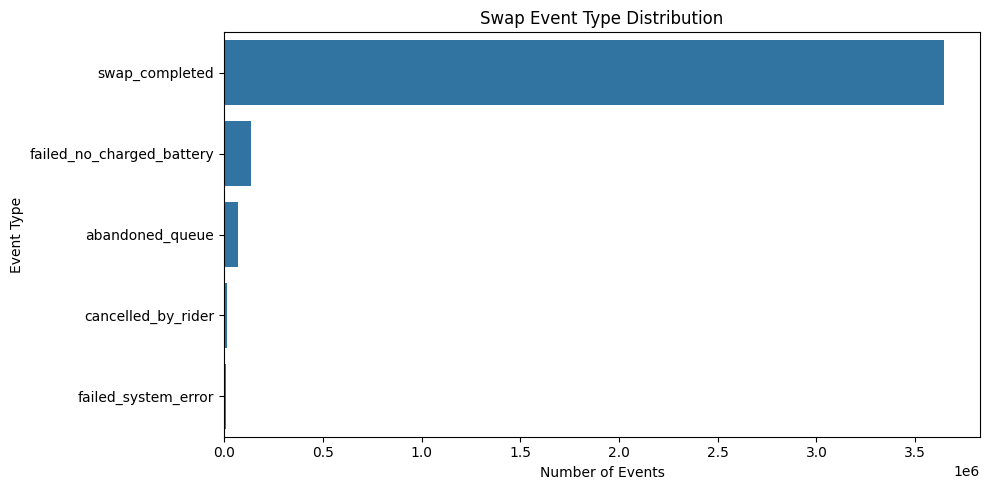

In [189]:
import matplotlib.pyplot as plt
import seaborn as sns

event_counts = swap_events["event_type"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(
    x=event_counts.values,
    y=event_counts.index
)

plt.title("Swap Event Type Distribution")
plt.xlabel("Number of Events")
plt.ylabel("Event Type")
plt.tight_layout()
plt.show()

<h1> Tariff Distribution </h1>

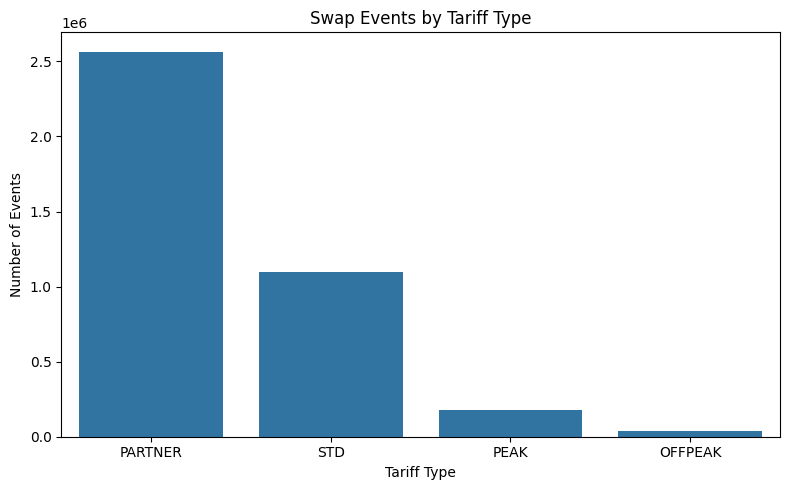

In [190]:
tariff_counts = swap_events["tariff_code"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=tariff_counts.index,
    y=tariff_counts.values
)

plt.title("Swap Events by Tariff Type")
plt.xlabel("Tariff Type")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.show()

<h1> Revenue by Tariff type </h1>

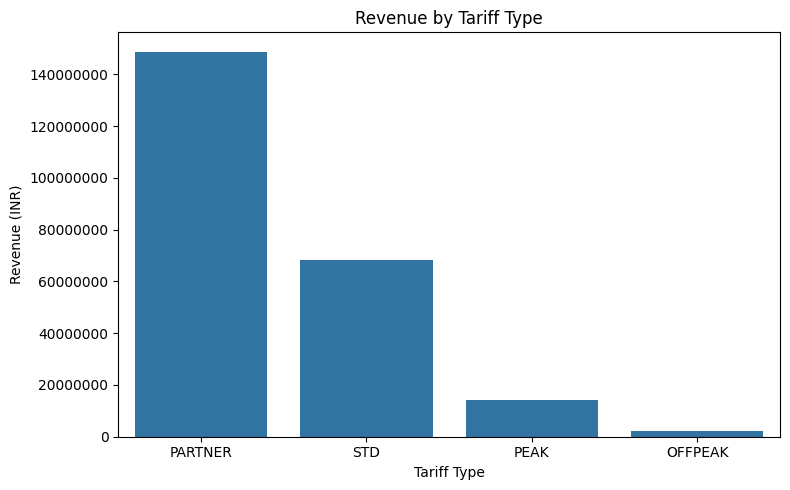

In [191]:
tariff_revenue = (
    swap_events[swap_events["is_completed"]]
    .groupby("tariff_code")["revenue_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=tariff_revenue.index,
    y=tariff_revenue.values
)

plt.title("Revenue by Tariff Type")
plt.xlabel("Tariff Type")
plt.ylabel("Revenue (INR)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

<h1> Distance since alst swap <h1>

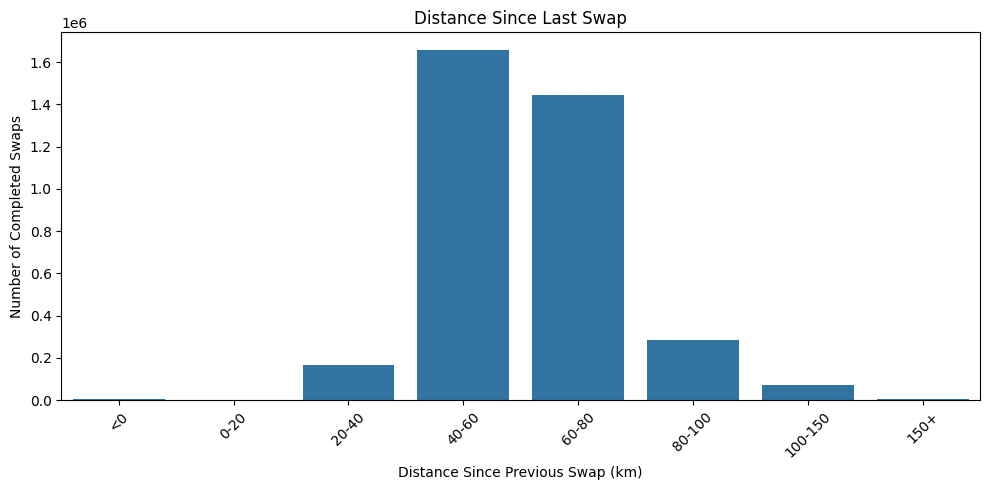

In [192]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x="distance_range_km",
    y="events",
    data=distance_distribution
)

plt.title("Distance Since Last Swap")
plt.xlabel("Distance Since Previous Swap (km)")
plt.ylabel("Number of Completed Swaps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [193]:
swap_events.to_csv(
    CLEAN_PATH + "swap_events_clean.csv",
    index=False
)

In [194]:
import os

file_path = CLEAN_PATH + "swap_events_clean.csv"

print("File exists:", os.path.exists(file_path))
print("File size (GB):", round(os.path.getsize(file_path) / (1024**3), 2))

File exists: True
File size (GB): 1.39
